In [3]:
# Flight Price Prediction Model Training

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the clean data
data_path = "D:/flightmate/backend/datasets/cleaned_flight_dataset.csv"
df = pd.read_csv(data_path)

# Ensure duration_minutes exists
if 'duration_minutes' not in df.columns:
    df['duration_minutes'] = df['duration'].apply(lambda x: int(x.split('h')[0])*60 + int(x.split('h')[1].split('m')[0]))

C:\Users\Dell\AppData\Local\Temp\ipykernel_11460\3783054071.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


In [9]:
# Feature Engineering
def prepare_features(df):
    """Prepare features for modeling"""
    features = pd.DataFrame()
    
    # Convert categorical features to codes
    features['airline'] = df['airline'].astype('category').cat.codes
    features['source_city'] = df['source_city'].astype('category').cat.codes
    features['destination_city'] = df['destination_city'].astype('category').cat.codes
    features['departure_time'] = df['departure_time'].astype('category').cat.codes
    features['arrival_time'] = df['arrival_time'].astype('category').cat.codes
    
    # Convert stops and class
    features['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})
    features['class'] = df['class'].map({'Economy': 0, 'Business': 1})
    
    # Numerical features
    features['duration_minutes'] = df['duration_minutes']
    features['days_left'] = df['days_left']
    
    return features

Model Performance:
MAE: 3421.79
MSE: 46197414.54
RMSE: 6796.87
R2 Score: 0.92


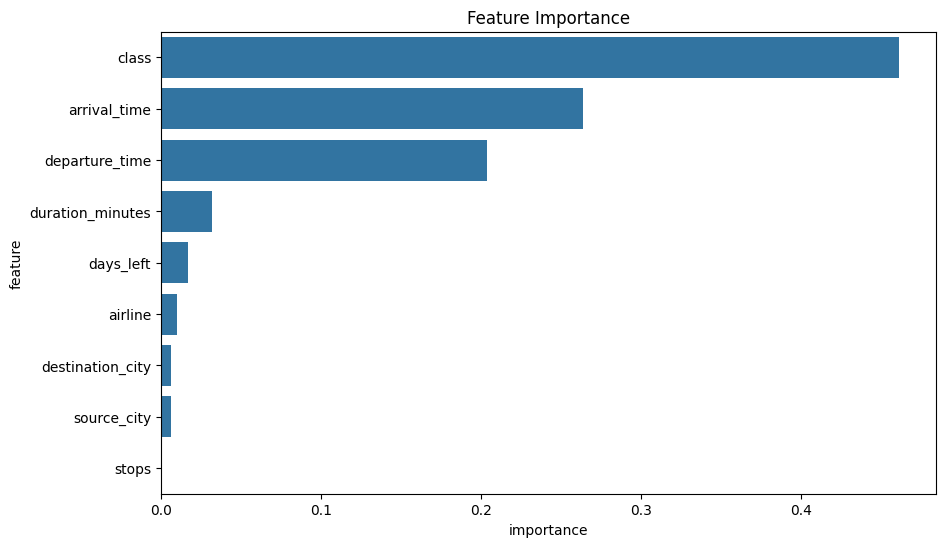

In [10]:
# Prepare data
X = prepare_features(df)
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("Model Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.savefig('../backend/static/images/feature_importance.png', bbox_inches='tight')
plt.show()


In [11]:
# Hyperparameter Tuning (optional)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), 
                         param_grid, 
                         cv=3,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# Save the model
os.makedirs("../backend/models", exist_ok=True)
joblib.dump(best_model, '../backend/models/price_model.pkl')

# Save the full dataset for recommendations
df.to_csv(data_path, index=False)

print("\nModel training complete and saved!")


Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

Model training complete and saved!


In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import joblib

# Load data
df = pd.read_csv('D:\\flightmate\\backend\\datasets\\cleaned_flight_dataset.csv')

# Prepare features
X = pd.DataFrame({
    'airline': df['airline'].astype('category').cat.codes,
    'source_city': df['source_city'].astype('category').cat.codes,
    'destination_city': df['destination_city'].astype('category').cat.codes,
    'departure_time': df['departure_time'].astype('category').cat.codes,
    'class': df['class'].map({'Economy': 0, 'Business': 1}),
    'days_left': df['days_left']
})
y = df['price']

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Save model
joblib.dump(model, 'D:\\flightmate\\backend\\models\\price_model.pkl')
print("Model trained and saved successfully!")

C:\Users\Dell\AppData\Local\Temp\ipykernel_5304\3951153204.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('D:\\flightmate\\backend\\datasets\\cleaned_flight_dataset.csv')


Model trained and saved successfully!
